# 2. Where does that camera think the robot is, and why is it wrong?

Same camera, same drive. Notebook 1 ended on a wall: the error is not centred on zero, and a covariance has no term for a mean. So go after the displacement itself.

---

**What this notebook implements**

The observation function the pipeline should be using: take the robot's own URDF meshes, put them at a pose, project into the camera, take the bounding box's bottom-centre, back-project (`nm.silhouette_bottom`). Zero fitted parameters. Also tried: carrying the offset as two extra states and letting the filter learn it.

**What came out**

As a diagnostic measurement-model comparison over 2,404 detections from the exact captures
`smoke1_20260716`, `smoke2_20260716`, `fusion_handover_20260721`, and `notebook_5hz`, all
pixels reprojected with current plain floor IPM, median Euclidean
$\lVert\text{observation}-\text{geometry prediction}\rVert$ falls
**4.69 cm → 1.98 cm** using odometry heading. A zero-heading control is worse than no
correction, so pose dependence contributes. On `notebook_5hz`, the one-camera augmented
state remains prior-dependent: its offset posterior mean is 5.6 cm from the run's
evaluation-only mean residual and retains 5.9 cm marginal standard deviation from a
10 cm prior. This is mechanism evidence, not current camera-accuracy evidence.

**What to do about it**

> **Predict the pose-dependent displacement when its geometry is known.** A constant offset
> and absolute position are not separately observable from one camera and odometry
> increments: add a constant to one and subtract it from the other, and no prediction
> changes. Multiple cameras can constrain relative offsets, which is notebook 4.

---

**Three quantities that must not be conflated**

For camera $c$ at detection $k$ this notebook uses:

$$\underbrace{\mathbf e_{c,k}}_{\text{instantaneous residual}}
=\underbrace{\mathbf y_{c,k}}_{\text{reported floor point}}
-\underbrace{\mathbf x_k^{\mathrm{GT}}}_{\text{robot origin}},\qquad
\underbrace{\mathbf b_c}_{\text{constant offset summary}}
=\frac{1}{n_c}\sum_k\mathbf e_{c,k},\qquad
\underbrace{\boldsymbol\eta_{c,k}}_{\text{centred remainder}}
=\mathbf e_{c,k}-\mathbf b_c.$$

$\mathbf R_c=\operatorname{Cov}(\boldsymbol\eta_{c,k})$ describes scatter, not the mean
$\mathbf b_c$. A third object, $\mathbf d_c(\mathbf x,\theta)$, is the displacement
predicted from camera and robot geometry; unlike $\mathbf b_c$, it may change with pose.
Ground truth is used only to evaluate $\mathbf e$ and $\mathbf b$, never by the online
filter or geometry correction.

The older driven captures have route/camera/yaw confounding and are retained here only to
test the silhouette mechanism on frozen rows. They must not be used to rank cameras or be
mixed with the balanced current comparison `PG-IPM-CURRENT`.

In [1]:
import notebook_data as nd
import notebook_model as nm
import notebook_views as nv
import numpy as np

nv.style()
commissioned = nm.commissioned_noise()

## 1. The run, and the one camera

In [2]:
capture = nd.load_capture()
truth_table = nd.load_truth(capture.name)
models = nd.camera_models()
window = nd.route_window(capture.name)
full = nm.Sequence(capture, truth_table, window=window)

# One camera, all the way through. Camera C offers the most observations of the four and
# the gate keeps every one of them, so nothing below is limited by data volume.
LEAD = "camera_C"
seq = nm.single_camera(full, LEAD)
n_obs = sum(1 for c in seq.camera if c is not None)

nv.report_single_camera(seq, full, LEAD, commissioned)

camera C alone: 160 observations over 998 steps (16% of them)
  the other three cameras' 189 detections are dropped; the filter dead-reckons through those stretches

                                             median  90th pct   worst
  all four cameras, distance from truth         8.1      10.5    16.6
  camera C only, distance from truth            8.1      11.8    15.3

  commissioned observation noise for C: 7.95 cm, one standard deviation.
  That number came from three other runs. The rest of this section asks what
  this run alone would say instead.


## 2. Where an observation actually comes from

In PP4 an observation is `y = C x + noise`, and the noise is given. Here the
observation has to be manufactured out of an image, in three steps:

1. the camera renders a frame;
2. a detector puts a box around the robot, and the **bottom-centre of that box** is
   taken as the point where the robot meets the floor;
3. that pixel is back-projected onto the floor plane.

Step 3 is a homography. With the camera's intrinsics $K$ and its rotation $R$ and
translation $t$, the map from a floor point to a pixel is

$$\tilde{\mathbf{p}} \;=\; \underbrace{K \begin{bmatrix} \mathbf{r}_1 & \mathbf{r}_2 & \mathbf{t}\end{bmatrix}}_{H}
  \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

and the observation is obtained by inverting it, $\begin{bmatrix} x & y & 1\end{bmatrix}^{\!\top} \propto H^{-1}\tilde{\mathbf{p}}$.
There are **no fitted parameters** in this step: $H$ comes from where the camera is
bolted and what lens it has. Every fitted correction that was tried made the result
worse, so the deployed system uses the plain homography.

Steps 2 and 3 are where the model's assumptions start to strain, and the next cell
shows why on a real frame.

In [3]:
example = nm.pick_example_frame(seq, capture)

nv.report_example_choice(example, seq)

example step: {'camera': 'camera_C', 'step': 376, 'stamp': 149.35699999999787, 'frame_stamp': 149.0, 'frame_path': 'frame_000149.000.png'}


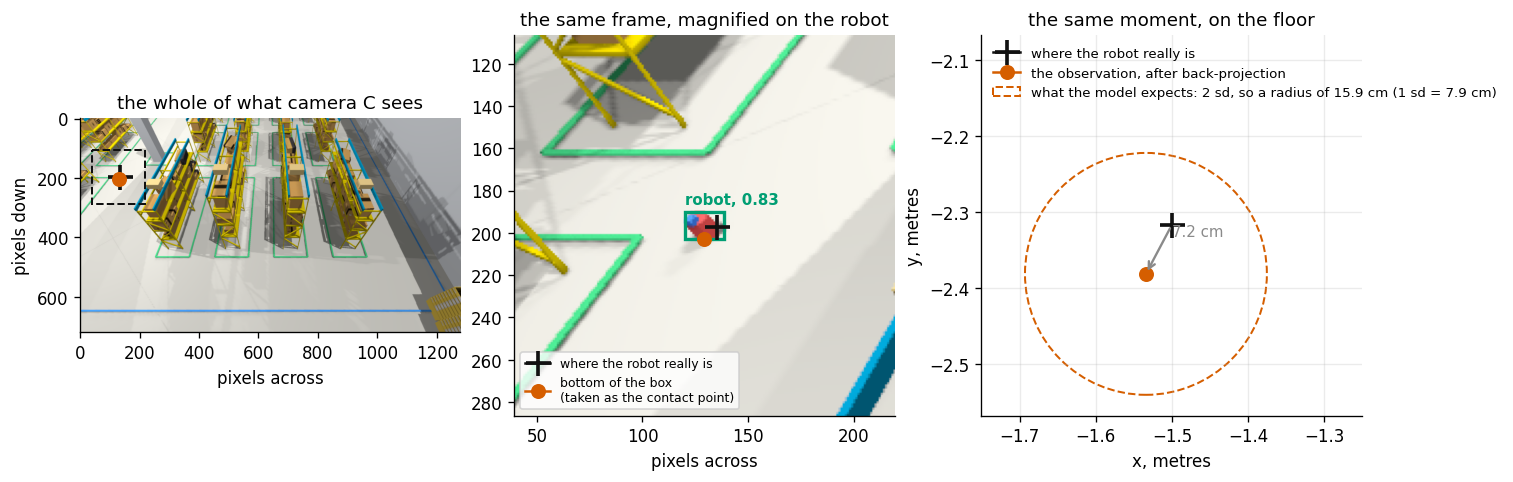

observation error at this step: 7.2 cm, against an assumed one-standard-deviation of 7.9 cm


In [4]:
nv.one_frame(example, seq, models, commissioned["sigma_total_m"])

### Why the bottom of the box is not the robot

So far this section has been about *whether* the detector fires. The rest of it is about
what the detection means when it does, because a detection in the right place is still
not a measurement of the robot.

The detector draws a box around the robot's **silhouette**. The bottom edge of that
silhouette is the lowest visible point of the body as seen *from that camera*, and
the TurtleBot3's body overhangs its wheel contact patch. So the point that gets
back-projected sits a little away from the true contact point, and which way it
sits depends on the direction the camera is looking from.

Look at the magnified panel again and note the scale. The true position and the
bottom of the box are a handful of pixels apart, and that handful of pixels is the
8.8 cm on the floor. The camera is six metres up and ten metres away, so its view of
the ground is steeply foreshortened and one pixel is worth a centimetre or more. The
detector is not sloppy — it is working at the resolution available to it, and the
geometry amplifies whatever is left.

The consequence for the model is precise: the residual $\mathbf e_{c,k}$ has a non-zero
sample mean $\mathbf b_c$, and $\mathbf{R}_c$ — a covariance of the centred remainder —
cannot represent or subtract that mean.

The next figure is the geometry of it. Two things have to line up for the observation
to be correct: the lowest visible point of the robot has to *be* the point where the
robot touches the floor, and the ray through that pixel has to meet the floor where the
model thinks the floor is. Neither is exactly true, and the error each introduces is
multiplied by the range-to-height ratio — about 2:1 for these cameras.

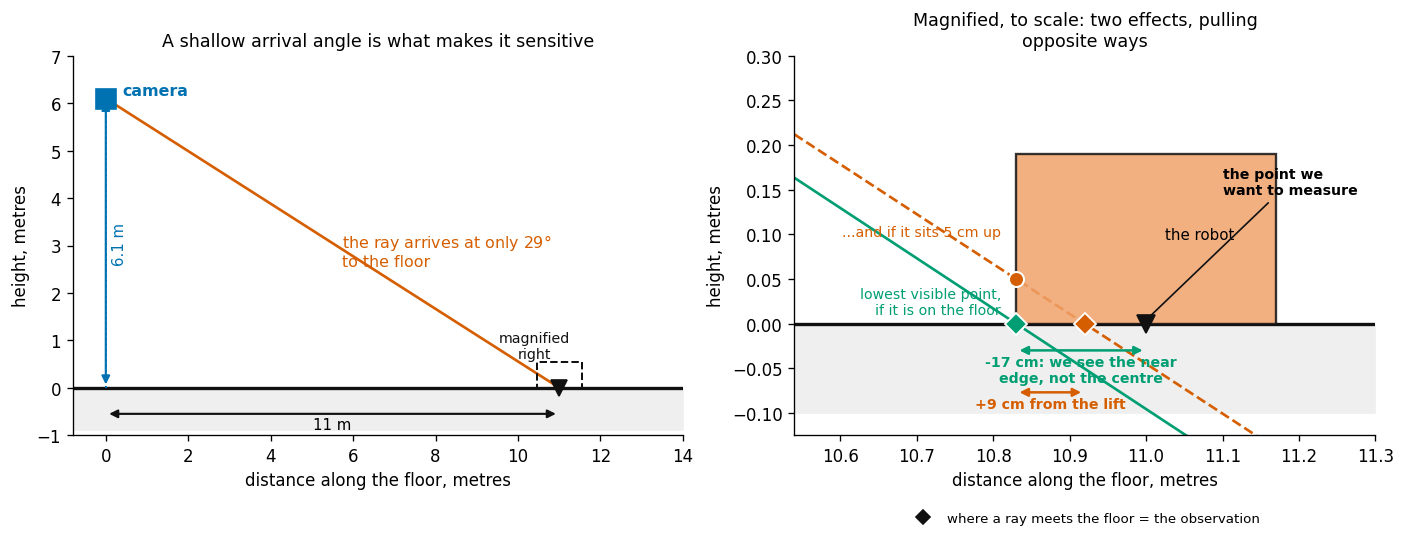

Camera 6.1 m up, robot 11 m away, so the ray arrives at 29 degrees and the multiplier is range/height = 1.8.
  seeing the near body edge instead of the centre: -17 cm (towards the camera)
  that edge appearing 5 cm off the floor: +9 cm (away from the camera)
  net, for this pose: -8 cm
Both depend on the bearing and on the robot's heading, and they partly cancel,
which is why the net offset is not something you can work out once and reuse.


In [5]:
nv.offset_geometry(models)

### What this camera's residual actually looks like

It is not scattered about zero. The arrow marks the sample mean $\mathbf b_C$ of this
diagnostic run; each dot is a separate $\mathbf e_{C,k}$. Calling the arrow an “offset” is
shorthand for this explicitly defined sample mean, not a permanent hardware constant.

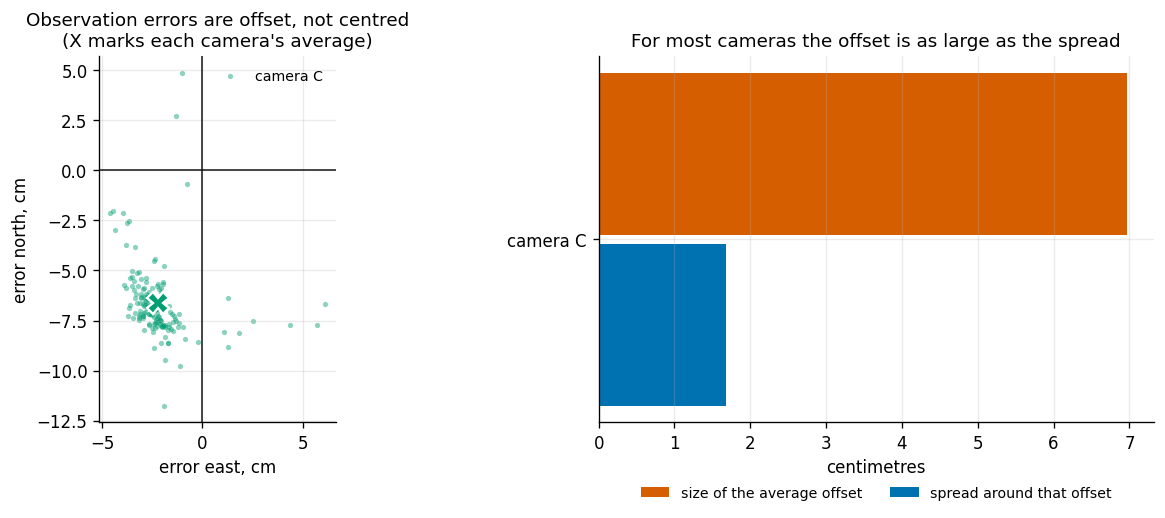

  camera C: average offset (  -2.2,   -6.6) cm, magnitude   7.0 cm, spread   1.7 cm, n=160


In [6]:
residuals = {LEAD: np.asarray([seq.y[k] - seq.truth[k] for k in range(seq.n_steps)
                               if seq.camera[k] == LEAD and np.isfinite(seq.truth[k, 0])])}

nv.per_camera_residuals(residuals)

## 3. Fixing the observation model instead

Notebook 1 tried to absorb the non-zero mean into covariance. A constant correction would
instead subtract $\mathbf b_c$. Here we test a stronger explanation: the displacement is
pose-dependent and should be part of the observation function itself.

But section 2 said what it actually is: the detector reports the bottom of the robot's
silhouette, and the pipeline pretends that is the robot's origin. That is not a nuisance,
it is a **wrong observation function**. The model says

$$\mathbf{y}_k = \mathbf{x}_k + \mathbf{r}_k$$

when the truth is closer to

$$\mathbf{y}_k \;=\; \underbrace{g_c\!\left(\mathbf{x}_k, \theta_k\right)}_{\text{where the silhouette's bottom lands}} \;+\; \mathbf{r}_k$$

where $g_c$ is computable: take the robot's shape, put it at position $\mathbf{x}_k$ with
heading $\theta_k$, project it into camera $c$, take the bottom-centre of the bounding
box, and back-project that. Every ingredient is known — the shape from the robot's own
mesh files, the camera from the world file, the projection from section 2.
Equivalently, define
$\mathbf d_c(\mathbf x,\theta)=g_c(\mathbf x,\theta)-\mathbf x$; the corrected
measurement is $\mathbf y_k-\mathbf d_c(\mathbf m_k^-,\hat\theta_k)$.

Two things follow, and they are the point of this section:

1. If $g_c$ is right, it should **predict** the observations, not merely describe them.
2. $g_c$ needs the heading $\theta_k$ — and the state $\mathbf{x}$ does not contain one.
   That is the real defect: not that `R` was wrong, but that the state is too small to
   express the thing that biases the measurement.

The heading is not lost, though. The odometry knows which way the robot is pointing.

In [7]:
odom_heading = nm.heading_from_odometry(seq)

nv.report_heading(seq, odom_heading, models)


heading available from odometry at 954 of 998 steps


### Does it predict?

For every detection in all four runs: put the robot where truth says it was, project its
shape, and see whether the predicted landing point is where the observation actually
landed. The fixed-heading row is the control — if the improvement were just "subtract a
constant per camera", a wrong heading would not matter.

                                n   median     p90    mean   removed
  no correction              2404    4.69c  10.58c   6.07c          
  true heading               2175    2.13c   6.02c   3.15c       55%
  odometry heading           2105    1.98c   5.37c   2.96c       58%
  heading assumed zero       2404    7.12c  10.01c   6.70c      -52%


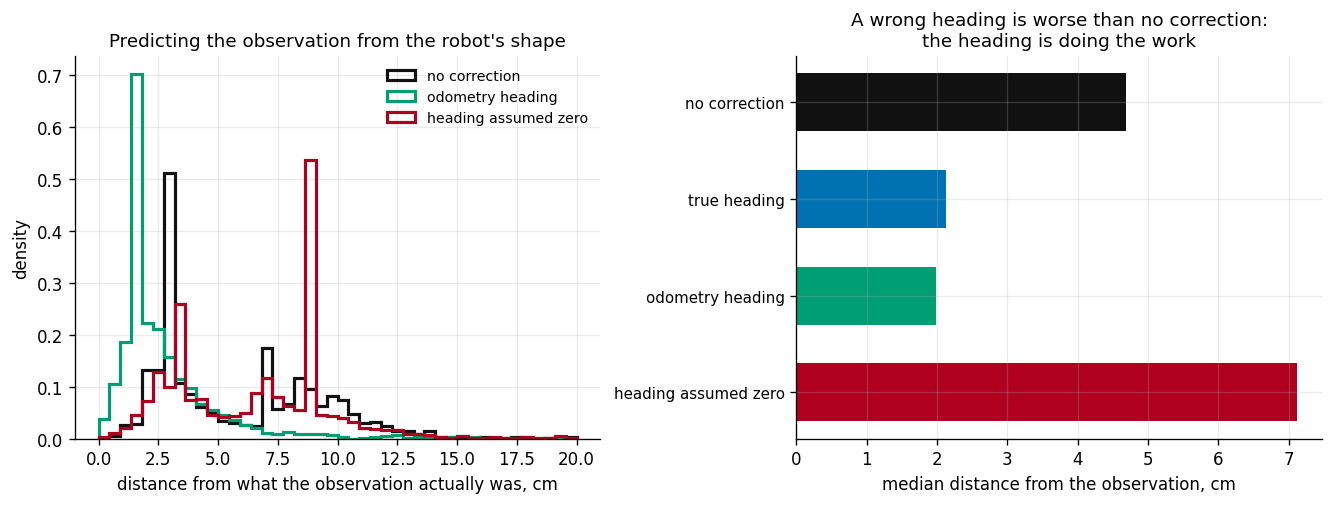

In [8]:
residual_by_heading = nm.prediction_residuals(
    list(nd.COMMISSIONING_CAPTURES) + [capture.name], models)

nv.does_it_predict(residual_by_heading, capture)

### And does it make the belief honest?

Prediction accuracy is not the goal — an honest belief is. So run the filter again with
the observation function corrected, using **only** things the filter has: the robot's mesh,
the camera's pose, the heading from odometry, and its own running estimate of position.
No ground truth enters the correction at any point.

For each observation, the predicted displacement at the filter's current estimate is
subtracted before the update. It is the cheap version of the right thing — the right thing
is to linearise $g_c$ and run an extended filter — but it is enough to answer the question.

corrected 160 of 160 observations with no ground truth

                                                  median NEES    score  RMSE cm
  commissioned R, as before                              4.23    -2.35     8.48
  observation function corrected                         0.46    -4.49     2.74
  corrected, and R back to scatter only                  0.68    -4.59     2.88
  offsets removed using ground truth (the ceiling)         0.46    -4.49     2.74

  an honest belief scores 1.39


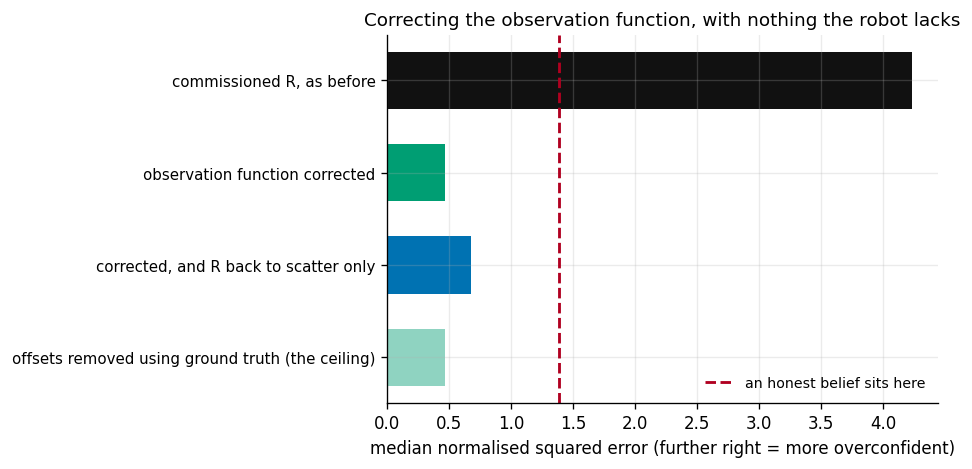

In [9]:
seq_geometry = nm.GeometryCorrected(seq, models, commissioned["R_total"], odom_heading)
forward_corrected = nm.kalman_filter(seq_geometry, commissioned["R_total"])
offsets = {LEAD: residuals[LEAD].mean(axis=0)}
seq_corrected = nm.OffsetCorrected(seq, offsets)

nv.geometry_honesty(seq, seq_geometry, forward_corrected, seq_corrected,
                    commissioned=commissioned)

## 4. Estimate a constant offset as state? Not from one camera alone

The other route is to stop predicting and let the filter estimate the offset: grow the
state from two numbers to four, $[\mathbf{x}, \mathbf{b}]$, with the camera observing
$\mathbf{x} + \mathbf{b}$ and a broad 10 cm prior on $\mathbf{b}$.

The augmented model used by `nm.offset_state_filter` is

$$\mathbf z_k=[\mathbf x_k^\top,\mathbf b^\top]^\top,\qquad
\mathbf y_k=\begin{bmatrix}\mathbf I&\mathbf I\end{bmatrix}\mathbf z_k+\mathbf r_k.$$

Here is the observability proof. For any constant $\boldsymbol\delta\in\mathbb R^2$, let

$$\mathbf x'_k=\mathbf x_k-\boldsymbol\delta,\qquad
\mathbf b'=\mathbf b+\boldsymbol\delta.$$

Then $\mathbf x'_k+\mathbf b'=\mathbf x_k+\mathbf b$, so every camera likelihood is
identical. The transition is also identical because
$\mathbf x'_k-\mathbf x'_{k-1}=\mathbf x_k-\mathbf x_{k-1}$. Therefore neither repeated
observations nor odometry increments distinguish the two parameterisations. In matrix
language, $[\boldsymbol\delta,-\boldsymbol\delta]$ is an unobservable direction of the
augmented system. Only the initial-position and offset priors choose a point along it.

So this should fail. It is worth running anyway, because *how* it fails is the useful part.

In [10]:
measured_offset = residuals[LEAD].mean(axis=0)
runs = {
    "not at all": nm.offset_state_filter(seq, commissioned["R_spread"], sigma_b_walk=0.0),
    "2 mm a step": nm.offset_state_filter(seq, commissioned["R_spread"], sigma_b_walk=0.002),
}

nv.report_offset_state_one(seq, LEAD, runs, measured_offset, commissioned)

  what camera C's offset actually averaged over this drive: (-2.2, -6.6) cm

     offset may move          estimate, cm    its own sd, cm   off by   NEES   RMSE
          not at all          (+1.5, -2.4)          5.9, 5.9      5.6   0.96   6.52
         2 mm a step          (-0.0, -0.0)          8.0, 8.1      7.0   0.76   7.17

  The prior on the offset was 10 cm in each axis. An estimate whose own sd is
  still most of that has not been informed by the data — it is repeating the prior
  back. Note the NEES looks fine: the belief is honest because it is WIDE, which is
  the filter being correct about knowing very little, not the offset being found.


## 5. `R` should not be one fixed matrix per camera either

Everything so far has carried one $\mathbf{R}_c$ per camera, fixed for the whole drive. That
is convenient and wrong, and section 2 already said why: the observation is a *pixel*, and
the map from pixel error to metres-on-the-floor is the derivative of the back-projection,

$$\mathbf{R}_k \;=\; J(u_k, v_k)\; \Sigma_{\text{px}}\; J(u_k, v_k)^{\!\top},
\qquad J = \frac{\partial (x, y)}{\partial (u, v)}$$

and $J$ depends on **where in the image the detection happened**. Near the bottom of the
frame the camera is looking almost straight down and a pixel is worth little; near the top it
is looking along the floor and a pixel is worth a lot. A single covariance per camera has to
average over that.

This is not a new proposal. It is what the deployed runtime already does —
`reliability.projection.project_observation_to_world_with_covariance` differentiates the
projection numerically and propagates $J \Sigma_{uv} J^{\!\top}$. The constant-per-camera
$\mathbf{R}$ used up to here was the simplification, adopted so that sections 3 to 5 could be
about one thing at a time.

Two questions: how much does $J$ actually vary, and is one pixel-noise number enough to
replace the twelve fitted ones?

### Where on the floor is `R` big?

The claim is spatial, so look at it that way. Every floor point, pushed through the camera
model to a pixel, differentiate the back-projection there, read off what one pixel of
detector error is worth in centimetres of floor. That is the same $J$ the deployed runtime
uses, so this is `R` itself and not an illustration of it.

The **size** grows with range — under the camera it looks down and a pixel is cheap, at the
far edge it looks along the floor and a pixel is dear. The **shape** turns with it: the
ellipse stretches along the camera's own sightline. And on the right, the two constants
from notebook 1 are drawn on the same axis as the quantity they are standing in for.

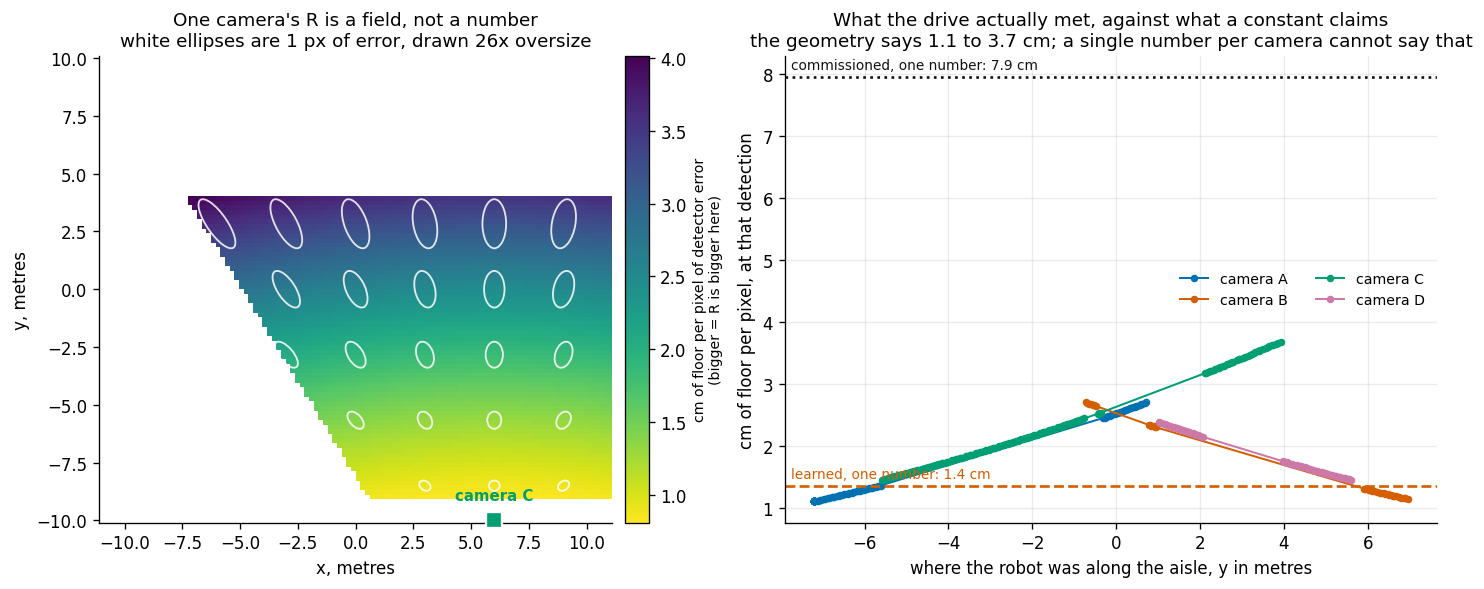

  camera C alone: a pixel is worth 0.81 cm of floor at best and 4.01 cm at worst, a factor of 5.0.
  over the drive, across all four cameras: 1.11 to 3.68 cm per pixel.
  A single covariance per camera has to average over that.


In [11]:
field = nm.pixel_worth_over_floor(models, LEAD)
learned_sigma = {c: float(np.sqrt(np.trace(nm.learn_R(seq)[0][c]) / 2)) for c in nd.CAMERAS}

nv.where_R_is_large(models, full, LEAD, field, constants={
    "commissioned, one number": (commissioned["sigma_total_m"], nv.C_TRUTH, ":"),
    "learned, one number": (learned_sigma, nv.C_FILTER, "--"),
})

## 6. What this leaves

The geometry-predicted displacement $\mathbf d_c(\mathbf x,\theta)$ is not random noise:
it belongs in the observation function. Predicting it needs the robot's shape, camera pose
and heading — all available online here, with no parameters fitted to this run.

What one camera cannot identify from these inputs is a constant $\mathbf b$ separately
from absolute position. Also, a fixed $\mathbf R_c$ discards the position dependence
introduced by projection. Multiple cameras can constrain relative offsets when their
observation windows connect through the route; notebook 4 states exactly which common
mode still remains unobservable.

---

*One recorded Gazebo session, one clock, no synthetic data. All estimator functions are
shared through `notebook_model.py` and all figures through `notebook_views.py`. Ground truth
fields are evaluation-only.*